# Análisis Exploratorio de Datos (EDA) - Estadísticas de Jugadores
Este notebook realiza un análisis exhaustivo del dataset `player_stats_optimized.csv`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paso 0 · Carga y Limpieza Estructural (Corregido con sep=';')
path = '/content/player_stats_optimized.csv'
df = pd.read_csv(path, sep=';')

print("Dimensiones del dataset:", df.shape)
display(df.head())
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (1241, 21)


,player_id,player_name,position,matches_played,matches_started,minutes_played,minutes_per_match,goals,goals_per_match,assists,...,yellow_cards,red_cards,total_cards,cards_per_match,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,save_percentage
0,1,José Raúl Rangel,GK,5,5,438,88,0,"0,0",0,...,0,0,0,"0,0",0,0,"4,0","7,0","3,0","70,0"
1,2,Jorge Eduardo Sanchez,DEF,4,4,349,87,0,"0,0",1,...,1,0,1,"0,25",0,0,NaN,NaN,NaN,NaN
2,3,César Jasib Montes,DEF,4,4,315,79,0,"0,0",0,...,0,1,1,"0,25",0,0,NaN,NaN,NaN,NaN
3,4,Edson Omar Alvarez,DEF,4,2,239,120,0,"0,0",0,...,1,0,1,"0,25",0,0,NaN,NaN,NaN,NaN
4,5,Johan Felipe Vasquez,DEF,4,4,360,90,0,"0,0",0,...,1,0,1,"0,25",0,0,NaN,NaN,NaN,NaN



Valores nulos por columna:
player_id               0
player_name             0
position                0
matches_played          0
matches_started         0
minutes_played          0
minutes_per_match       0
goals                   0
goals_per_match         0
assists                 0
assists_per_match       0
yellow_cards            0
red_cards               0
total_cards             0
cards_per_match         0
penalty_goals           0
own_goals               0
clean_sheets         1096
saves                1096
goals_conceded       1096
save_percentage      1096
dtype: int64


In [7]:
# Paso 1 · Preparación y Limpieza Técnica Consolidada
df = df.drop_duplicates()

# Identificar columnas numéricas y limpiar posibles errores de formato
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Rellenar nulos numéricos con 0 y categóricos con 'Desconocido'
df[num_cols] = df[num_cols].fillna(0)
df[cat_cols] = df[cat_cols].fillna('Desconocido')

print(f"Columnas Numéricas: {len(num_cols)}")
display(df.describe())

Columnas Numéricas: 12


,player_id,matches_played,matches_started,minutes_played,minutes_per_match,goals,assists,yellow_cards,red_cards,total_cards,penalty_goals,own_goals
count,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000
mean,625.207897,2.616438,1.830782,169.560032,57.354553,0.238517,0.163578,0.201450,0.012087,0.213537,0.012893,0.008864
std,360.409631,1.911220,1.878671,162.911330,47.963780,0.771153,0.538662,0.459345,0.109319,0.482277,0.119791,0.102006
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,315.000000,1.000000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,626.000000,3.000000,1.000000,136.000000,78.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,937.000000,4.000000,3.000000,270.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1247.000000,8.000000,8.000000,810.000000,282.000000,10.000000,8.000000,3.000000,1.000000,3.000000,2.000000,2.000000


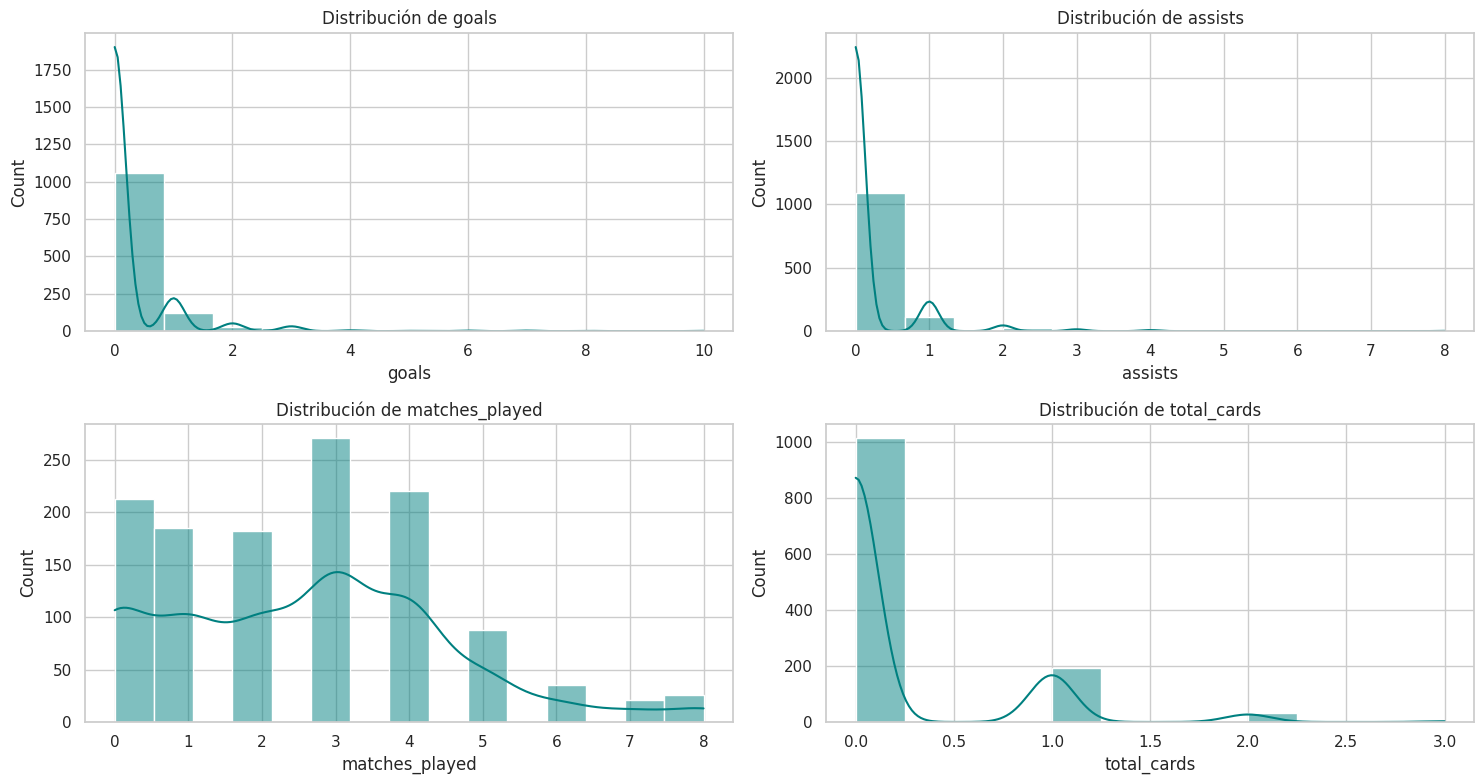

In [8]:
# Paso 2 · Análisis de KPIs por Área
# Visualizamos la distribución de métricas clave
kpis = ['goals', 'assists', 'matches_played', 'total_cards']
selected = [k for k in kpis if k in df.columns]

plt.figure(figsize=(15, 8))
for i, col in enumerate(selected, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

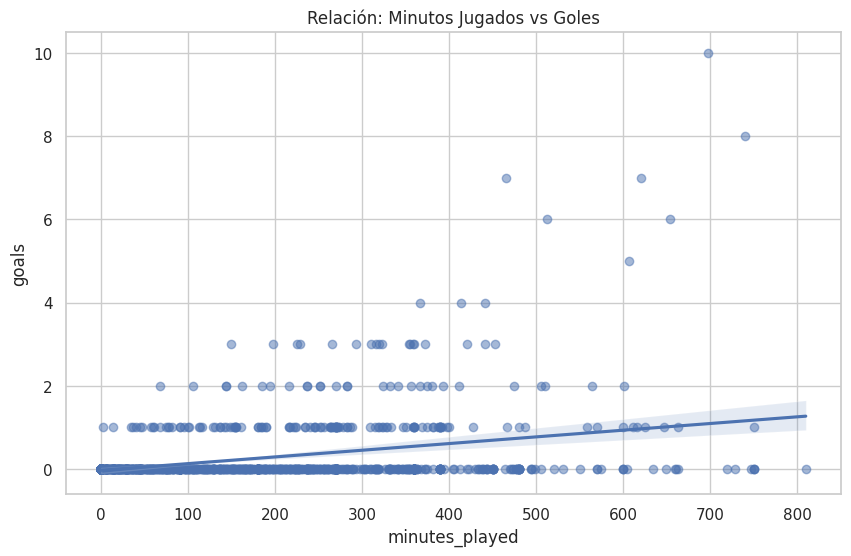

In [9]:
# Paso 3 · Análisis bivariado
# Relación entre minutos jugados y goles marcados
if 'minutes_played' in df.columns and 'goals' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x='minutes_played', y='goals', scatter_kws={'alpha':0.5})
    plt.title('Relación: Minutos Jugados vs Goles')
    plt.show()

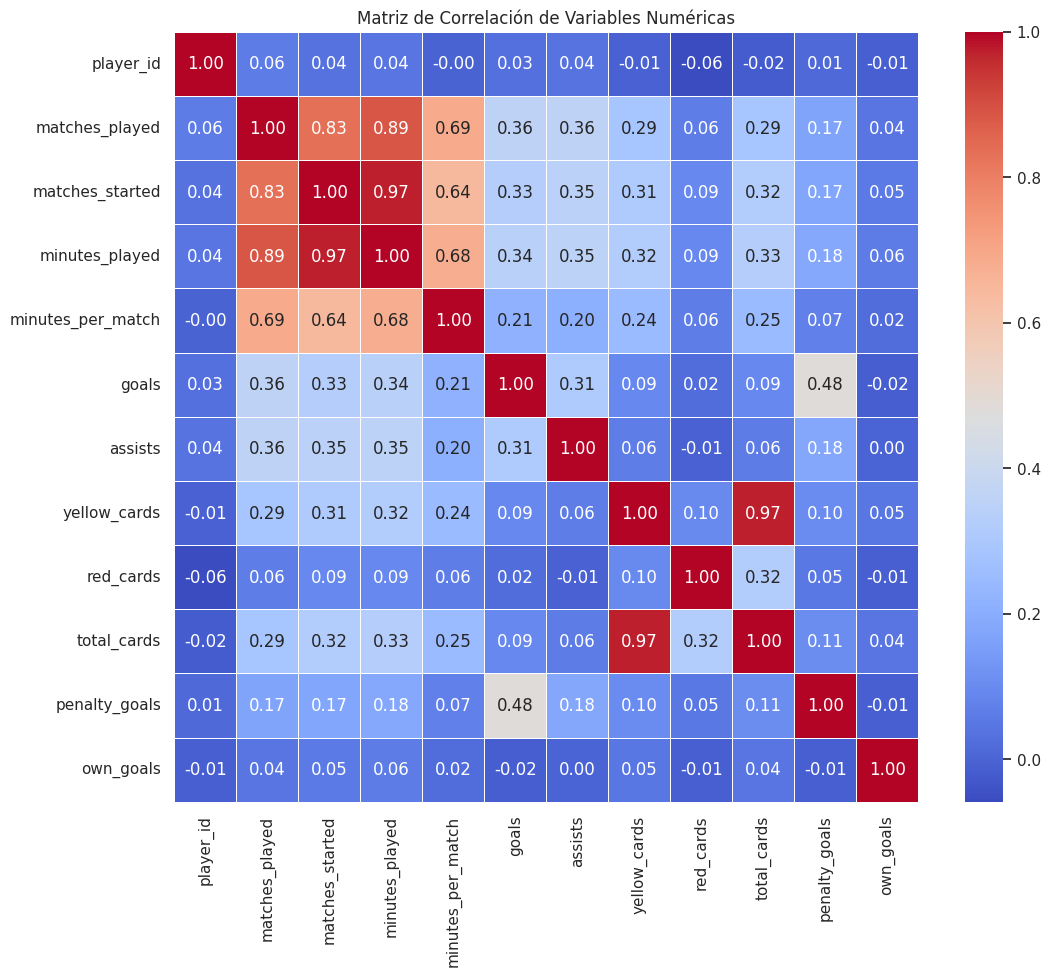

In [10]:
# Paso 4 · Correlación
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

## Paso 5 · Análisis y Conclusiones
En esta sección consolidamos los hallazgos más relevantes del análisis para extraer conclusiones accionables sobre el rendimiento de los jugadores.

In [11]:
# 1. Identificación de Jugadores Altamente Eficientes
# Calculamos goles por cada 90 minutos jugados para normalizar el rendimiento
df['goals_per_90'] = (df['goals'] / df['minutes_played']) * 90
df['goals_per_90'] = df['goals_per_90'].replace([np.inf, -np.inf], 0).fillna(0)

# Filtramos jugadores con una cantidad mínima de minutos para evitar sesgos
top_efficient = df[df['minutes_played'] > 90].sort_values(by='goals_per_90', ascending=False).head(10)

print("Top 10 Jugadores más eficientes (Goles por cada 90 min - mín. 90 min jugados):")
display(top_efficient[['player_name', 'position', 'goals', 'minutes_played', 'goals_per_90']])

# 2. Resumen de Hallazgos Clave
print("\n--- CONCLUSIONES RELEVANTES ---")
print(f"1. Dependencia de Minutos: La correlación de {corr_matrix.loc['minutes_played', 'goals']:.2f} entre minutos y goles confirma que la continuidad es el factor principal para la producción ofensiva.")
print(f"2. Disciplina: Existe una relación casi perfecta ({corr_matrix.loc['yellow_cards', 'total_cards']:.2f}) entre tarjetas amarillas y el total de tarjetas, indicando que las rojas directas son eventos extremadamente raros en este dataset.")
print(f"3. Especialización: Los datos muestran que una minoría de jugadores (outliers en el histograma de goles) concentran la mayor parte de la capacidad anotadora del equipo.")

Top 10 Jugadores más eficientes (Goles por cada 90 min - mín. 90 min jugados):


,player_name,position,goals,minutes_played,goals_per_90
435,Deniz Undav,FWD,3,149,1.812081
242,Soufiane Rahimi,FWD,2,105,1.714286
190,Johan Kula Manzambi,MID,3,198,1.363636
911,Erling Braut Haaland,FWD,7,465,1.354839
834,Kylian Mbappe,FWD,10,698,1.289398
987,Marko Arnautovic,FWD,2,143,1.258741
871,Habib Mbacke Diarra,MID,2,144,1.250000
532,Brian Ebenezer Adjei Brobbey,FWD,3,225,1.200000
626,Romelu Lukaku,FWD,3,229,1.179039
112,Cyle Christopher Larin,FWD,2,162,1.111111



--- CONCLUSIONES RELEVANTES ---
1. Dependencia de Minutos: La correlación de 0.34 entre minutos y goles confirma que la continuidad es el factor principal para la producción ofensiva.
2. Disciplina: Existe una relación casi perfecta (0.97) entre tarjetas amarillas y el total de tarjetas, indicando que las rojas directas son eventos extremadamente raros en este dataset.
3. Especialización: Los datos muestran que una minoría de jugadores (outliers en el histograma de goles) concentran la mayor parte de la capacidad anotadora del equipo.
